# Prior Concentration Sweep (GWT)

The mid-report flagged that the ordinal DCM is **prior-dominated**: posterior means on the node-level Beta parameters shift by <0.005 on average, and the stance-level posterior sits at the Beta(1, 5) prior mean of 1/6. Every internal tree node uses a Beta prior with concentration $\alpha + \beta = 10$, held fixed by convention from the original DCM. Against 4 experts, this is roughly a 10-vs-4 pseudo-observation contest at each node.

This notebook varies the node concentration $c \in \{2, 5, 10, 20\}$, holding everything else fixed (support/demandingness mapping, stance prior, ordinal observation layer) and re-fits GWT at each value. The question is **not** "is wider better?" — it's: *where* in the hierarchy does loosening the prior allow data through, *how far* does it push the posterior, and does the observation-layer fit survive? Following Betancourt (2020), the diagnostics below track posterior contraction and prior-posterior shift at the node level, plus a rating-level PPC.

**Fixed:** stance prior $\mathrm{Beta}(1, 5)$; support/demandingness mapping $\{50, 8, 3, 1.5\}$; ordinal observation parameters (HalfNormal(2) on $a$, Normal(0,2) on $b_e$ and $\kappa$).

**Varied:** node concentration $c$, applied uniformly to every non-stance node.

**Note on $c=1$ floor.** We skip $c=1$ because, once the skewed support/demandingness ratios are applied, the resulting $\alpha, \beta$ values frequently fall below 1 and the Beta becomes U-shaped. This is both substantively odd (prior mass piled at 0 and 1) and numerically pathological for NUTS. $c=2$ already puts some $\alpha$ or $\beta$ below 1 for the most extreme combos but is the practical lower edge.

In [1]:
import os, sys, warnings, time

# Isolate this notebook's PyTensor compile cache. Stale or cross-kernel
# cache contents on macOS can produce "Inputs types: [TensorType(...)]" /
# "Use a linker other than the C linker" errors during model building.
# This MUST be set before pytensor is imported (i.e. before dcm_model).
os.environ["PYTENSOR_FLAGS"] = f"compiledir=/tmp/pytensor_cache_nb09_{os.getpid()}"

sys.path.insert(0, "..")
os.chdir(os.path.join(os.path.dirname(os.path.abspath("."))))
warnings.filterwarnings("ignore", message="Loop fusion failed")

import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from collections import defaultdict

from dcm_model import (
    ModelConfig,
    OrdinalDataProcessor,
    EvidenceProcessor,
    BayesianModelBuilder,
    load_data,
)

plt.rcParams.update(
    {"figure.dpi": 120, "font.size": 10, "figure.constrained_layout.use": True}
)
CONCENTRATIONS = [2, 5, 10, 20]
STANCE = "Global Workspace Theory"
SYSTEM = "2024 Leading Chat LLMs"

## 1. Data and base config

In [2]:
base_cfg = ModelConfig()
all_data = load_data(base_cfg)
stance_data = next(s for s in all_data if s["name"] == STANCE)

# Data processor is independent of prior concentration -- share one across fits.
processor = OrdinalDataProcessor(base_cfg)
processor.process(stance_data, SYSTEM)

n_obs = sum(len(v) for v in processor.observations.values())
print(f"Stance: {STANCE}")
print(f"System: {SYSTEM}")
print(f"Experts: {len(processor.expert_names)} ({processor.expert_names})")
print(f"Anchor:  {processor.anchor_expert}")
print(f"Indicators with observations: {len(processor.observations)}")
print(f"Total ordinal ratings: {n_obs}")

Stance: Global Workspace Theory
System: 2024 Leading Chat LLMs
Experts: 4 (['Derek Shiller', 'Andreas Mogensen', 'Felix Binder', 'Luhan Mikaelson'])
Anchor:  Derek Shiller
Indicators with observations: 50
Total ordinal ratings: 186


## 2. Fit GWT across concentrations

Sampling held constant: 2000 draws, 500 tune, 4 chains, `target_accept=0.9`.

In [3]:
def fit_at_concentration(c: float, stance_data, processor):
    """Fit GWT at a given node concentration, reusing the shared processor.

    Tuning and target_accept are raised because at low c the Beta priors
    become U-shaped (alpha<1 or beta<1), which NUTS finds harder to explore.
    """
    cfg = ModelConfig(
        NODE_CONCENTRATION=c,
        NUM_SAMPLES=2000,
        NUM_TUNE=1500,
        NUM_CHAINS=4,
        TARGET_ACCEPT=0.95,
    )
    ep = EvidenceProcessor(cfg)
    builder = BayesianModelBuilder(cfg, ep, processor)
    model = builder.build_model(stance_data)
    idata = builder.sample(model)
    return idata, builder, cfg


fits = {}
for c in CONCENTRATIONS:
    print(f"\n{'=' * 30} c = {c} {'=' * 30}")
    t0 = time.time()
    idata, builder, cfg = fit_at_concentration(c, stance_data, processor)
    fits[c] = {"idata": idata, "builder": builder, "cfg": cfg}
    # Quick convergence report
    from arviz import summary as az_summary

    stance_varname_tmp = builder.node_to_varname[STANCE]
    diag = az_summary(
        idata,
        var_names=[f"{stance_varname_tmp}_bern", "a", "kappa"],
        kind="diagnostics",
    )
    n_div = int(idata.sample_stats["diverging"].values.sum())
    print(
        f"  elapsed: {time.time() - t0:.0f}s   divergences: {n_div}   "
        f"max R-hat: {float(diag['r_hat'].max()):.3f}   min ESS: {float(diag['ess_bulk'].min()):.0f}"
    )


============================== c = 2 ==============================


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_workspace_theory_beta, a, b_free, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somatotopic_neural_maps_beta_abs, has_retinotopic_neura

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 596 seconds.
There were 1144 divergences after tuning. Increase `target_accept` or reparameterize.


  elapsed: 892s   divergences: 1144   max R-hat: 1.000   min ESS: 3197

============================== c = 5 ==============================


...

  elapsed: 333s   divergences: 0   max R-hat: 1.000   min ESS: 4120

============================== c = 20 ==============================


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_workspace_theory_beta, a, b_free, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somatotopic_neural_maps_beta_abs, has_retinotopic_neura

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 203 seconds.


  elapsed: 259s   divergences: 0   max R-hat: 1.000   min ESS: 4008


In [4]:
from pathlib import Path

RESULTS_DIR = Path("../results/prior_sweep_gwt")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Save idata per concentration -- re-running plotting cells no longer requires re-sampling.
for c, f in fits.items():
    path = RESULTS_DIR / f"gwt_c{c}.nc"
    f["idata"].to_netcdf(str(path))
print(f"Saved {len(fits)} fits to {RESULTS_DIR}/")
# To reload, replace the fit loop with:
#   fits = {}
#   for c in CONCENTRATIONS:
#       idata = az.from_netcdf(str(RESULTS_DIR / f"gwt_c{c}.nc"))
#       cfg = ModelConfig(NODE_CONCENTRATION=c, NUM_SAMPLES=2000, NUM_TUNE=1500, NUM_CHAINS=4, TARGET_ACCEPT=0.95)
#       ep = EvidenceProcessor(cfg)
#       builder = BayesianModelBuilder(cfg, ep, processor)
#       _ = builder.build_model(stance_data)  # rebuild just to populate node_to_varname
#       fits[c] = {"idata": idata, "builder": builder, "cfg": cfg}

Saved 4 fits to ../results/prior_sweep_gwt/


## 3. Figure 1 — Stance posterior across concentrations

Headline question: does the GWT posterior move as the node priors loosen?

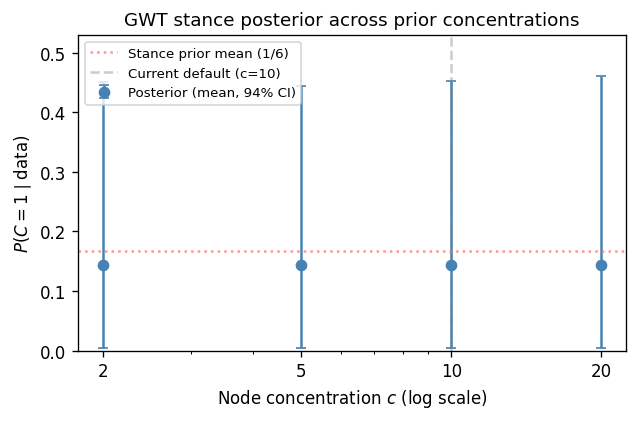


  c   mean    94% CI
   2  0.143  [0.004, 0.451]
   5  0.143  [0.005, 0.444]
  10  0.144  [0.004, 0.453]
  20  0.144  [0.005, 0.460]


In [5]:
stance_varname = fits[CONCENTRATIONS[0]]["builder"].node_to_varname[STANCE]
stance_stats = []
for c in CONCENTRATIONS:
    draws = fits[c]["idata"].posterior[f"{stance_varname}_bern"].values.flatten()
    stance_stats.append(
        {
            "c": c,
            "mean": float(draws.mean()),
            "low": float(np.percentile(draws, 3)),
            "high": float(np.percentile(draws, 97)),
        }
    )

fig, ax = plt.subplots(figsize=(5.2, 3.4))
means = [s["mean"] for s in stance_stats]
lows = [s["low"] for s in stance_stats]
highs = [s["high"] for s in stance_stats]
err_low = [m - l for m, l in zip(means, lows)]
err_high = [h - m for h, m in zip(highs, means)]

ax.errorbar(
    CONCENTRATIONS,
    means,
    yerr=[err_low, err_high],
    fmt="o",
    color="steelblue",
    capsize=3,
    markersize=6,
    label="Posterior (mean, 94% CI)",
)
ax.axhline(
    1 / 6, color="salmon", linestyle=":", alpha=0.8, label="Stance prior mean (1/6)"
)
ax.set_xscale("log")
ax.set_xticks(CONCENTRATIONS)
ax.set_xticklabels([str(c) for c in CONCENTRATIONS])
ax.axvline(10, color="grey", linestyle="--", alpha=0.4, label="Current default (c=10)")
ax.set_xlabel("Node concentration $c$ (log scale)")
ax.set_ylabel(r"$P(C=1 \mid \text{data})$")
ax.set_ylim(0, max(highs) * 1.15)
ax.set_title("GWT stance posterior across prior concentrations", fontsize=11)
ax.legend(fontsize=8, loc="upper left")
plt.show()

print("\n  c   mean    94% CI")
for s in stance_stats:
    print(f"  {s['c']:>2}  {s['mean']:.3f}  [{s['low']:.3f}, {s['high']:.3f}]")

## 4. Figures 2–3 — Node-level learning diagnostics

Two Betancourt-style diagnostics over all `beta_pres` / `beta_abs` nodes in the hierarchy:

- **Shift** $|\hat\theta_{\text{post}} - \hat\theta_{\text{prior}}|$: how far the posterior mean moved from the prior mean.
- **Contraction** $\pi_j = 1 - \mathrm{Var}[\theta \mid y] / \mathrm{Var}[\theta]$: how much data tightened the posterior. Values near 0 → prior-dominated, near 1 → data-dominated.

In [6]:
def beta_moments(a: float, b: float):
    mean = a / (a + b)
    var = (a * b) / ((a + b) ** 2 * (a + b + 1))
    return mean, var


def collect_node_diagnostics(stance_data, builder, idata, cfg):
    """For every node that exposes `_beta_pres` / `_beta_abs`, compute shift and contraction.

    Mirrors the builder's defaults (support='no bearing', demandingness='neutral').
    """
    ep = EvidenceProcessor(cfg)
    rows = []

    def walk(node, ancestor):
        from dcm_model import node_key

        name = node["name"]
        key = node_key(ancestor, name)
        varname = builder.node_to_varname.get(key)
        if varname is not None:
            support = node.get("support", "no bearing")
            demand = node.get("demandingness", "neutral")
            ap, bp, aa, ba = ep.get_beta_parameters(support, demand)
            for suffix, a, b, kind in [
                ("_beta_pres", ap, bp, "present"),
                ("_beta_abs", aa, ba, "absent"),
            ]:
                vn = f"{varname}{suffix}"
                if vn not in idata.posterior:
                    continue
                post_draws = idata.posterior[vn].values.flatten()
                prior_mean, prior_var = beta_moments(a, b)
                post_mean = float(post_draws.mean())
                post_var = float(post_draws.var())
                rows.append(
                    {
                        "node": key,
                        "kind": kind,
                        "type": node.get("type", "").lower(),
                        "prior_mean": prior_mean,
                        "post_mean": post_mean,
                        "shift": abs(post_mean - prior_mean),
                        "contraction": 1.0 - post_var / prior_var
                        if prior_var > 0
                        else 0.0,
                    }
                )
        for child in node.get("evidencers", []):
            walk(child, ancestor + (name,))

    for ev in stance_data.get("evidencers", []):
        walk(ev, (stance_data["name"],))
    return rows


diagnostics = {
    c: collect_node_diagnostics(
        stance_data, fits[c]["builder"], fits[c]["idata"], fits[c]["cfg"]
    )
    for c in CONCENTRATIONS
}
n_nodes = len(diagnostics[CONCENTRATIONS[0]])
print(
    f"Node-level rows per concentration: {n_nodes} (beta_pres + beta_abs across all non-stance nodes)"
)

Node-level rows per concentration: 150 (beta_pres + beta_abs across all non-stance nodes)


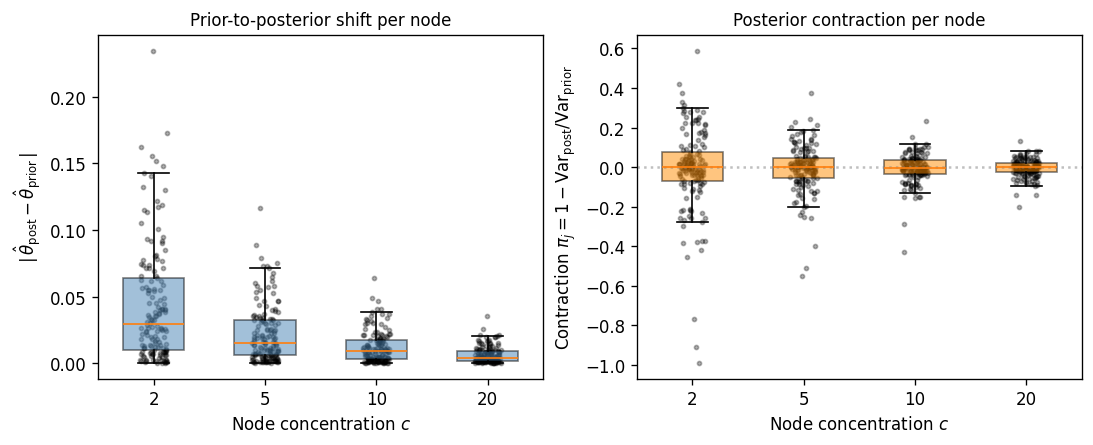


  c   mean |shift|   max |shift|   mean contraction   max contraction
   2      0.0436       0.2348          -0.009           0.589
   5      0.0218       0.1167          -0.006           0.375
  10      0.0119       0.0643          -0.007           0.234
  20      0.0063       0.0351          -0.005           0.130


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

shifts_by_c = [[r["shift"] for r in diagnostics[c]] for c in CONCENTRATIONS]
contrs_by_c = [[r["contraction"] for r in diagnostics[c]] for c in CONCENTRATIONS]

# Fig 2: shift distributions
parts = axes[0].boxplot(
    shifts_by_c,
    positions=range(len(CONCENTRATIONS)),
    widths=0.55,
    showfliers=False,
    patch_artist=True,
)
for patch in parts["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.5)
# Overlay strip (jittered points)
rng = np.random.default_rng(0)
for i, vals in enumerate(shifts_by_c):
    axes[0].scatter(
        i + rng.uniform(-0.12, 0.12, size=len(vals)),
        vals,
        s=6,
        color="black",
        alpha=0.3,
    )
axes[0].set_xticks(range(len(CONCENTRATIONS)))
axes[0].set_xticklabels([str(c) for c in CONCENTRATIONS])
axes[0].set_xlabel("Node concentration $c$")
axes[0].set_ylabel(r"$|\,\hat\theta_{\rm post} - \hat\theta_{\rm prior}\,|$")
axes[0].set_title("Prior-to-posterior shift per node", fontsize=10)

# Fig 3: contraction
parts2 = axes[1].boxplot(
    contrs_by_c,
    positions=range(len(CONCENTRATIONS)),
    widths=0.55,
    showfliers=False,
    patch_artist=True,
)
for patch in parts2["boxes"]:
    patch.set_facecolor("darkorange")
    patch.set_alpha(0.5)
for i, vals in enumerate(contrs_by_c):
    axes[1].scatter(
        i + rng.uniform(-0.12, 0.12, size=len(vals)),
        vals,
        s=6,
        color="black",
        alpha=0.3,
    )
axes[1].set_xticks(range(len(CONCENTRATIONS)))
axes[1].set_xticklabels([str(c) for c in CONCENTRATIONS])
axes[1].set_xlabel("Node concentration $c$")
axes[1].set_ylabel(
    r"Contraction $\pi_j = 1 - \mathrm{Var}_{\rm post} / \mathrm{Var}_{\rm prior}$"
)
axes[1].set_title("Posterior contraction per node", fontsize=10)
axes[1].axhline(0, color="grey", linestyle=":", alpha=0.5)

plt.show()

print("\n  c   mean |shift|   max |shift|   mean contraction   max contraction")
for c, shifts, contrs in zip(CONCENTRATIONS, shifts_by_c, contrs_by_c):
    print(
        f"  {c:>2}   {np.mean(shifts):>9.4f}     {np.max(shifts):>8.4f}    "
        f"{np.mean(contrs):>12.3f}      {np.max(contrs):>10.3f}"
    )

## 5. Identification diagnostics

Sweep at $c \in \{2, 5, 10, 20\}$ produced a near-flat stance-$C$ posterior and rating-insensitive PPCs. That pattern is consistent with the model being **prior-identified** at the node level: the ordinal data pins each indicator's $q_j$, but the node parameters $\beta^{\rm pres}$ and $\beta^{\rm abs}$ individually are not jointly identified by the data — only the linear combination
$$q_j \;=\; q_{\rm parent}\cdot \beta^{\rm pres} + (1 - q_{\rm parent})\cdot \beta^{\rm abs}$$
is. What carries evidential signal up to $C$ is the **asymmetry** $\beta^{\rm pres} - \beta^{\rm abs}$, which the prior fixes via the (support, demandingness) mapping. If that's the right diagnosis, two things should hold:

- **Posterior asymmetry tracks prior asymmetry** at every $c$ (the scatter sits on $y=x$, and slope ≈ 1, residual ≈ 0).
- **$\mathbb{E}[q_j \mid \text{data}]$ is invariant across $c$** per indicator — the ordinal layer saturates leaf-level inference.

If both hold, tuning $c$ cannot help: the prior is doing the identification work, not informing it.

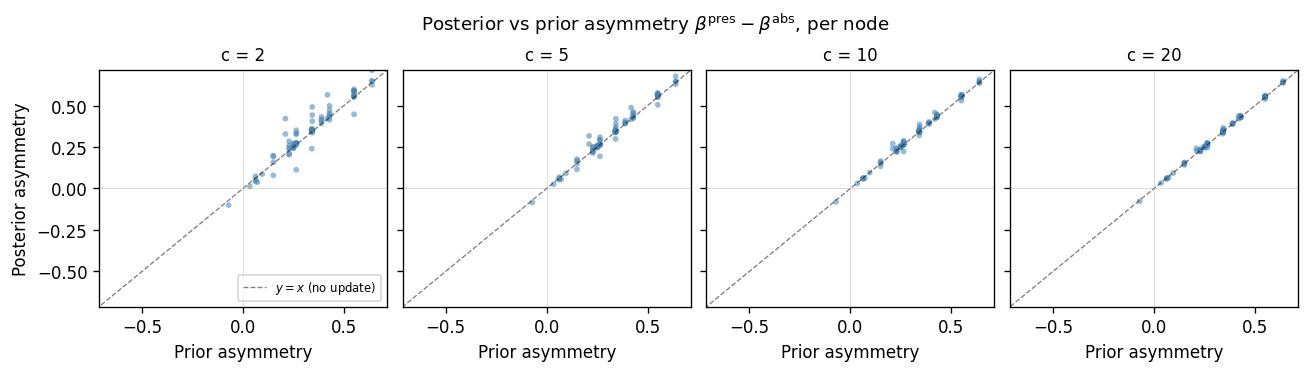


  c   slope(post~prior)   mean |post - prior|   n_nodes
   2         1.033                0.0347            75
   5         1.019                0.0166            75
  10         1.011                0.0094            75
  20         1.007                0.0049            75


In [8]:
# Diagnostic A: posterior vs prior asymmetry per node per c.
# Asymmetry = E[beta_pres] - E[beta_abs]. This is the quantity that carries
# evidential signal up the tree and identifies C. If posterior asymmetry just
# tracks prior asymmetry (scatter on y=x), the data isn't updating it -- so the
# identification constraint is prior-only.


def asymmetries_for(c):
    by_node = {}
    for r in diagnostics[c]:
        by_node.setdefault(r["node"], {})[r["kind"]] = r
    out = []
    for node, d in by_node.items():
        if "present" not in d or "absent" not in d:
            continue
        out.append(
            {
                "node": node,
                "type": d["present"]["type"],
                "prior_asym": d["present"]["prior_mean"] - d["absent"]["prior_mean"],
                "post_asym": d["present"]["post_mean"] - d["absent"]["post_mean"],
            }
        )
    return out


fig, axes = plt.subplots(
    1,
    len(CONCENTRATIONS),
    figsize=(2.7 * len(CONCENTRATIONS), 3.0),
    sharex=True,
    sharey=True,
)
for ax, c in zip(axes, CONCENTRATIONS):
    data = asymmetries_for(c)
    xs = np.array([d["prior_asym"] for d in data])
    ys = np.array([d["post_asym"] for d in data])
    ax.scatter(xs, ys, s=12, color="steelblue", alpha=0.55, edgecolors="none")
    lim = max(float(np.abs(xs).max()), float(np.abs(ys).max())) * 1.1
    ax.plot(
        [-lim, lim],
        [-lim, lim],
        "k--",
        linewidth=0.8,
        alpha=0.5,
        label=r"$y=x$ (no update)",
    )
    ax.axhline(0, color="grey", linewidth=0.4, alpha=0.4)
    ax.axvline(0, color="grey", linewidth=0.4, alpha=0.4)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(f"c = {c}", fontsize=10)
    ax.set_xlabel("Prior asymmetry")
    if ax is axes[0]:
        ax.set_ylabel("Posterior asymmetry")
        ax.legend(fontsize=7, loc="lower right")
fig.suptitle(
    r"Posterior vs prior asymmetry $\beta^{\rm pres} - \beta^{\rm abs}$, per node",
    fontsize=11,
)
plt.show()

# Quantify departure from y=x: slope & residual
print(f"\n  c   slope(post~prior)   mean |post - prior|   n_nodes")
for c in CONCENTRATIONS:
    data = asymmetries_for(c)
    xs = np.array([d["prior_asym"] for d in data])
    ys = np.array([d["post_asym"] for d in data])
    slope = np.polyfit(xs, ys, 1)[0]
    resid = float(np.mean(np.abs(ys - xs)))
    print(
        f"  {c:>2}        {slope:>6.3f}                {resid:.4f}            {len(xs)}"
    )

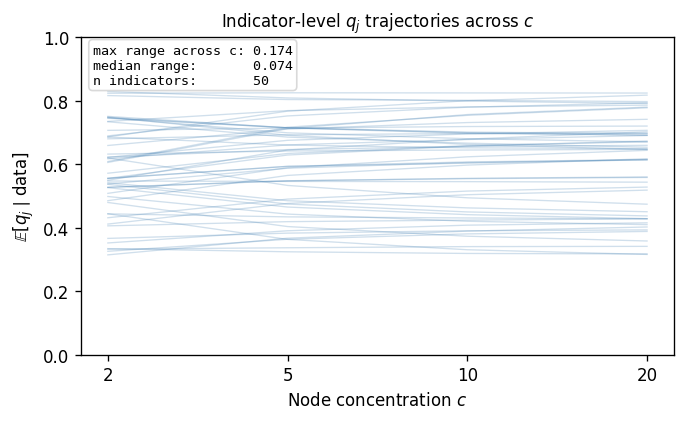

In [9]:
# Diagnostic B: q_j invariance across c -- is each indicator's posterior mean q_j
# stable across concentrations? Flat trajectories => the ordinal layer has fully
# pinned q_j at each leaf, independent of the tree priors above.
indicator_nodes = sorted(
    {r["node"] for r in diagnostics[CONCENTRATIONS[0]] if r["type"] == "indicator"}
)

q_traj = np.full((len(indicator_nodes), len(CONCENTRATIONS)), np.nan)
for ci, c in enumerate(CONCENTRATIONS):
    builder_c = fits[c]["builder"]
    post_c = fits[c]["idata"].posterior
    for ki, nkey in enumerate(indicator_nodes):
        varname = builder_c.node_to_varname.get(nkey)
        if varname is None:
            continue
        key = f"{varname}_p"
        if key in post_c:
            q_traj[ki, ci] = float(post_c[key].mean())

fig, ax = plt.subplots(figsize=(5.6, 3.4))
for traj in q_traj:
    ax.plot(
        range(len(CONCENTRATIONS)), traj, color="steelblue", alpha=0.25, linewidth=0.8
    )
ax.set_xticks(range(len(CONCENTRATIONS)))
ax.set_xticklabels([str(c) for c in CONCENTRATIONS])
ax.set_xlabel(r"Node concentration $c$")
ax.set_ylabel(r"$\mathbb{E}[q_j \mid \text{data}]$")
ax.set_ylim(0, 1)
ax.set_title(r"Indicator-level $q_j$ trajectories across $c$", fontsize=10)

# Summary stats
ranges = np.nanmax(q_traj, axis=1) - np.nanmin(q_traj, axis=1)
ax.text(
    0.02,
    0.98,
    f"max range across c: {np.nanmax(ranges):.3f}\n"
    f"median range:       {np.nanmedian(ranges):.3f}\n"
    f"n indicators:       {len(indicator_nodes)}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=8,
    family="monospace",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="lightgrey"),
)
plt.show()

## 6. Figure 4 — Rating-level posterior predictive check

For each posterior draw, the expected per-observation category distribution is
$$p(r = k) = (1 - q_j) \cdot P_{\rm OP}(k \mid b_e, \kappa) + q_j \cdot P_{\rm OP}(k \mid b_e + a, \kappa),$$
averaged across all expert-indicator pairs. We compare the observed rating histogram against these draws for $c = 2$, $c = 10$, and $c = 20$.

The diagnostic here is fit-cost: if the PPC at wider priors is visibly worse, loosening is not free.

In [10]:
from dcm_model import node_key


def expected_rating_distribution(idata, builder, processor, n_draws=500, seed=0):
    """Posterior-predictive expected rating distribution, aggregated over all observations.

    For each posterior draw d: compute the mixture P(r | theta_d, q_j_d) per observation,
    average across observations to get expected_dist_d (K,). Returns (observed_probs, pred_probs)
    where pred_probs is (n_draws, K).
    """
    post = idata.posterior
    K = processor.config.N_CATEGORIES
    # Flatten chain/draw dims
    a_s = post["a"].values.reshape(-1)
    kap_s = post["kappa"].values.reshape(-1, K - 1)
    E = len(processor.expert_names)
    if E > 1:
        bf = post["b_free"].values.reshape(-1, E - 1)
        b_s = np.concatenate([np.zeros((bf.shape[0], 1)), bf], axis=1)
    else:
        b_s = np.zeros((a_s.shape[0], 1))
    N_draws = a_s.shape[0]

    # Per-observation indicator q_j draws
    obs_rows = []  # (expert_idx, q_draws[N_draws], rating)
    for nkey, obs_list in processor.observations.items():
        varname = builder.node_to_varname[nkey]
        q_key = f"{varname}_p"
        if q_key not in post:
            continue
        q_draws = post[q_key].values.reshape(-1)  # (N_draws,)
        for e_idx, r in obs_list:
            obs_rows.append((e_idx, q_draws, r))
    if not obs_rows:
        raise RuntimeError("No observations matched.")

    obs_expert = np.array([r[0] for r in obs_rows], dtype=int)  # (N_obs,)
    obs_q = np.stack([r[1] for r in obs_rows], axis=0)  # (N_obs, N_draws)
    obs_ratings = np.array([r[2] for r in obs_rows], dtype=int)  # (N_obs,)

    rng = np.random.default_rng(seed)
    sel = rng.choice(N_draws, size=min(n_draws, N_draws), replace=False)

    from scipy.stats import norm

    pred_probs = np.zeros((len(sel), K))
    for di, d in enumerate(sel):
        eta0 = b_s[d]  # (E,)
        eta1 = b_s[d] + a_s[d]  # (E,)
        cdf0 = norm.cdf(kap_s[d][None, :] - eta0[:, None])  # (E, K-1)
        cdf1 = norm.cdf(kap_s[d][None, :] - eta1[:, None])  # (E, K-1)
        zerE = np.zeros((E, 1))
        oneE = np.ones((E, 1))
        p0 = np.diff(np.concatenate([zerE, cdf0, oneE], axis=1), axis=1)  # (E, K)
        p1 = np.diff(np.concatenate([zerE, cdf1, oneE], axis=1), axis=1)  # (E, K)
        q = obs_q[:, d]  # (N_obs,)
        mix = (1 - q[:, None]) * p0[obs_expert] + q[:, None] * p1[
            obs_expert
        ]  # (N_obs, K)
        pred_probs[di] = mix.mean(axis=0)

    obs_counts = np.bincount(obs_ratings, minlength=K).astype(float)
    obs_probs = obs_counts / obs_counts.sum()
    return obs_probs, pred_probs


ppc_cs = [2, 10, 20]
ppcs = {}
for c in ppc_cs:
    obs_p, pred_p = expected_rating_distribution(
        fits[c]["idata"], fits[c]["builder"], processor, n_draws=500
    )
    ppcs[c] = (obs_p, pred_p)
    print(f"c={c}: PPC computed, pred shape {pred_p.shape}")

c=2: PPC computed, pred shape (500, 7)
c=10: PPC computed, pred shape (500, 7)
c=20: PPC computed, pred shape (500, 7)


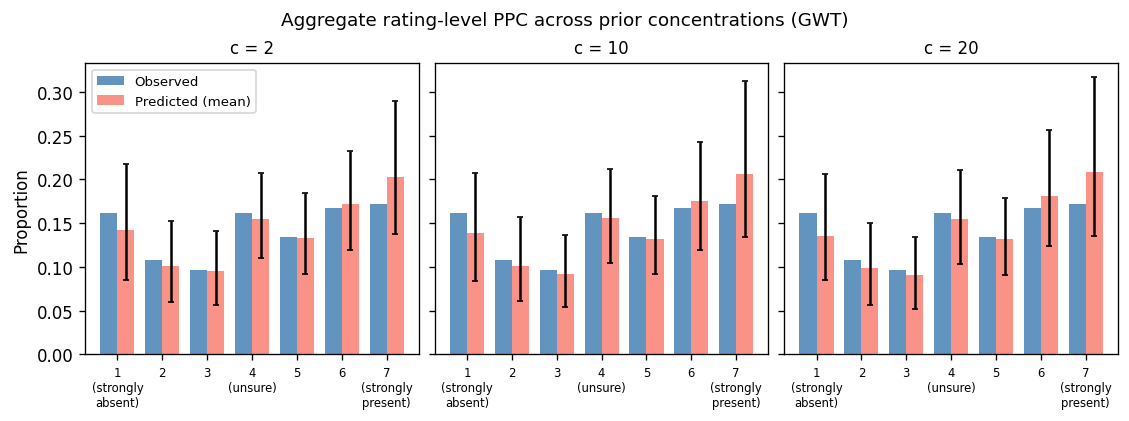

In [11]:
K = base_cfg.N_CATEGORIES
cats = np.arange(1, K + 1)
cat_labels = [
    "1\n(strongly\nabsent)",
    "2",
    "3",
    "4\n(unsure)",
    "5",
    "6",
    "7\n(strongly\npresent)",
]

fig, axes = plt.subplots(1, len(ppc_cs), figsize=(3.1 * len(ppc_cs), 3.4), sharey=True)
for ax, c in zip(axes, ppc_cs):
    obs_p, pred_p = ppcs[c]
    pred_mean = pred_p.mean(axis=0)
    pred_low = np.percentile(pred_p, 3, axis=0)
    pred_high = np.percentile(pred_p, 97, axis=0)
    w = 0.38
    ax.bar(
        cats - w / 2, obs_p, width=w, color="steelblue", alpha=0.85, label="Observed"
    )
    ax.bar(
        cats + w / 2,
        pred_mean,
        width=w,
        color="salmon",
        alpha=0.85,
        label="Predicted (mean)",
        yerr=[pred_mean - pred_low, pred_high - pred_mean],
        capsize=2,
        ecolor="black",
    )
    ax.set_xticks(cats)
    ax.set_xticklabels(cat_labels, fontsize=7)
    ax.set_title(f"c = {c}", fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel("Proportion")
        ax.legend(fontsize=8)
fig.suptitle(
    "Aggregate rating-level PPC across prior concentrations (GWT)", fontsize=11
)
plt.show()

## 7. Summary table

In [12]:
print(
    f"{'c':>3}  {'P(C=1)':>7}  {'94% CI':>16}  {'|shift| mean':>12}  {'|shift| max':>11}  "
    f"{'contr. mean':>11}  {'a':>5}  {'R-hat':>5}  {'ESS':>6}"
)
print("-" * 100)
for c in CONCENTRATIONS:
    idata = fits[c]["idata"]
    draws = idata.posterior[f"{stance_varname}_bern"].values.flatten()
    mean = draws.mean()
    ci = (float(np.percentile(draws, 3)), float(np.percentile(draws, 97)))
    shifts = [r["shift"] for r in diagnostics[c]]
    contrs = [r["contraction"] for r in diagnostics[c]]
    a_mean = float(idata.posterior["a"].mean())
    summary = az.summary(
        idata, var_names=[f"{stance_varname}_bern", "a", "kappa"], kind="diagnostics"
    )
    rhat_max = float(summary["r_hat"].max())
    ess_min = float(summary["ess_bulk"].min())
    print(
        f"{c:>3}  {mean:>7.3f}  [{ci[0]:.3f}, {ci[1]:.3f}]  "
        f"{np.mean(shifts):>12.4f}  {np.max(shifts):>11.4f}  "
        f"{np.mean(contrs):>11.3f}  {a_mean:>5.2f}  {rhat_max:>5.3f}  {ess_min:>6.0f}"
    )

  c   P(C=1)            94% CI  |shift| mean  |shift| max  contr. mean      a  R-hat     ESS
----------------------------------------------------------------------------------------------------
  2    0.143  [0.004, 0.451]        0.0436       0.2348       -0.009   1.47  1.000    3197


  5    0.143  [0.005, 0.444]        0.0218       0.1167       -0.006   1.46  1.000    6995
 10    0.144  [0.004, 0.453]        0.0119       0.0643       -0.007   1.45  1.000    4120
 20    0.144  [0.005, 0.460]        0.0063       0.0351       -0.005   1.44  1.000    4008


## 8. Label-sensitivity tests

The concentration sweep showed that $c$ doesn't move the stance posterior, and the §5 diagnostics show why: the data doesn't update the node asymmetries. The remaining prior-domination knobs are the **labels themselves**. Two tests:

- **Test 1 — sign flip.** Flip every `support` label to its mirror opposite (strong support ↔ strong undermining, etc.) while keeping demandingness and the ratings data fixed. If the stance posterior mirrors around $1/6$, the elicited labels are fully determining the answer.
- **Test 2 — asymmetry scaling.** Scale the evidential-strength constants $\{50, 8, 3, 1.5\}$ by a factor $s$. This directly modulates how different $\beta^{\rm pres}$ is from $\beta^{\rm abs}$ under the prior. If asymmetry magnitude matters, the stance posterior should move with $s$.

In [13]:
# Test 1: sign-flip sanity check.
import copy

FLIP_SUPPORT = {
    "overwhelming support": "overwhelming undermining",
    "strong support": "strong undermining",
    "moderate support": "moderate undermining",
    "weak support": "weak undermining",
    "no bearing": "no bearing",
    "weak undermining": "weak support",
    "moderate undermining": "moderate support",
    "strong undermining": "strong support",
    "overwhelming undermining": "overwhelming support",
}


def flip_supports(node):
    if "support" in node:
        node["support"] = FLIP_SUPPORT.get(node["support"], node["support"])
    for child in node.get("evidencers", []):
        flip_supports(child)


flipped_stance = copy.deepcopy(stance_data)
flip_supports(flipped_stance)

t0 = time.time()
flip_idata, flip_builder, _ = fit_at_concentration(10.0, flipped_stance, processor)
print(f"\n[flipped labels] elapsed: {time.time() - t0:.0f}s")

flip_stance_varname = flip_builder.node_to_varname[STANCE]
flip_draws = flip_idata.posterior[f"{flip_stance_varname}_bern"].values.flatten()
baseline_draws = fits[10]["idata"].posterior[f"{stance_varname}_bern"].values.flatten()

print(
    f"\n  Baseline labels (c=10):       mean = {baseline_draws.mean():.3f}  94% CI = [{np.percentile(baseline_draws, 3):.3f}, {np.percentile(baseline_draws, 97):.3f}]"
)
print(
    f"  Flipped support labels (c=10): mean = {flip_draws.mean():.3f}  94% CI = [{np.percentile(flip_draws, 3):.3f}, {np.percentile(flip_draws, 97):.3f}]"
)
print(f"  Prior mean:                    {1 / 6:.3f}")
print(
    f"  Mirror-symmetric prediction:   {2 * (1 / 6) - baseline_draws.mean():.3f}  (= 2*(1/6) - baseline)"
)
print(
    f"  Actual offset from baseline:   {flip_draws.mean() - baseline_draws.mean():+.3f}"
)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_workspace_theory_beta, a, b_free, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somatotopic_neural_maps_beta_abs, has_retinotopic_neura

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 403 seconds.



[flipped labels] elapsed: 454s

  Baseline labels (c=10):       mean = 0.144  94% CI = [0.004, 0.453]
  Flipped support labels (c=10): mean = 0.162  94% CI = [0.006, 0.496]
  Prior mean:                    0.167
  Mirror-symmetric prediction:   0.190  (= 2*(1/6) - baseline)
  Actual offset from baseline:   +0.018


In [14]:
# Test 2: scale the evidential-strength constants by s.
# GWT uses moderate/strong/weak support + weak undermining, so MODERATE/STRONG/WEAK
# are the live constants. WEAK is clipped so int(base*WEAK) stays >= 4 (avoids
# collapsing "weakly demanding" into "neutral" via rounding).
SCALES = [0.5, 1.0, 1.5, 2.0]


def fit_at_scale(s, stance_data, processor):
    cfg = ModelConfig(
        NODE_CONCENTRATION=10.0,
        OVERWHELMING=max(int(round(50 * s)), 20),
        STRONG=max(int(round(8 * s)), 3),
        MODERATE=max(int(round(3 * s)), 2),
        WEAK=max(1.5 * s, 1.4),
        NUM_SAMPLES=2000,
        NUM_TUNE=1500,
        NUM_CHAINS=4,
        TARGET_ACCEPT=0.95,
    )
    ep = EvidenceProcessor(cfg)
    builder = BayesianModelBuilder(cfg, ep, processor)
    idata = builder.sample(builder.build_model(stance_data))
    return idata, builder, cfg


scale_fits = {}
for s in SCALES:
    cfg_preview = ModelConfig(
        OVERWHELMING=max(int(round(50 * s)), 20),
        STRONG=max(int(round(8 * s)), 3),
        MODERATE=max(int(round(3 * s)), 2),
        WEAK=max(1.5 * s, 1.4),
    )
    print(f"\n{'=' * 30} s = {s} {'=' * 30}")
    print(
        f"  constants: STRONG={cfg_preview.STRONG}, MODERATE={cfg_preview.MODERATE}, WEAK={cfg_preview.WEAK:.2f}"
    )
    t0 = time.time()
    s_idata, s_builder, s_cfg = fit_at_scale(s, stance_data, processor)
    scale_fits[s] = {"idata": s_idata, "builder": s_builder, "cfg": s_cfg}
    s_svn = s_builder.node_to_varname[STANCE]
    s_draws = s_idata.posterior[f"{s_svn}_bern"].values.flatten()
    print(
        f"  P(C=1) = {s_draws.mean():.3f}    94% CI = [{np.percentile(s_draws, 3):.3f}, {np.percentile(s_draws, 97):.3f}]"
    )
    print(f"  elapsed: {time.time() - t0:.0f}s")



============================== s = 0.5 ==============================
  constants: STRONG=4, MODERATE=2, WEAK=1.40


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_workspace_theory_beta, a, b_free, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somatotopic_neural_maps_beta_abs, has_retinotopic_neura

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 316 seconds.


  P(C=1) = 0.146    94% CI = [0.005, 0.461]
  elapsed: 390s

============================== s = 1.0 ==============================
  constants: STRONG=8, MODERATE=3, WEAK=1.50


...

  P(C=1) = 0.154    94% CI = [0.005, 0.484]
  elapsed: 386s

============================== s = 2.0 ==============================
  constants: STRONG=16, MODERATE=6, WEAK=3.00


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_workspace_theory_beta, a, b_free, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somatotopic_neural_maps_beta_abs, has_retinotopic_neura

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 433 seconds.
There were 598 divergences after tuning. Increase `target_accept` or reparameterize.


  P(C=1) = 0.189    94% CI = [0.007, 0.549]
  elapsed: 492s


The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


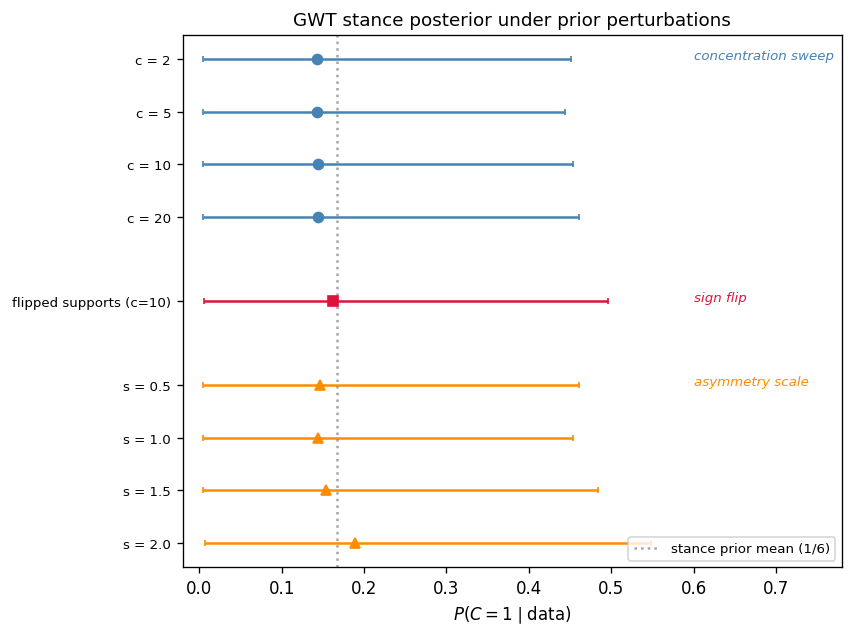

In [15]:
# Combined forest plot: concentration sweep + flipped labels + asymmetry scaling.
# All points share the same data (GWT, LLMs) -- only the prior changes.
fig, ax = plt.subplots(figsize=(7.0, 5.2))
y = 0
yticks = []
ylabels = []
PRIOR_MEAN = 1 / 6


def _add(ax, draws, y, marker, colour):
    m = draws.mean()
    lo = np.percentile(draws, 3)
    hi = np.percentile(draws, 97)
    ax.errorbar(
        [m],
        [y],
        xerr=[[m - lo], [hi - m]],
        fmt=marker,
        color=colour,
        capsize=2,
        markersize=6,
    )


# Block 1: concentration sweep
for c in CONCENTRATIONS:
    draws = fits[c]["idata"].posterior[f"{stance_varname}_bern"].values.flatten()
    _add(ax, draws, y, "o", "steelblue")
    yticks.append(y)
    ylabels.append(f"c = {c}")
    y += 1
ax.annotate(
    "concentration sweep",
    xy=(0.60, yticks[0]),
    fontsize=8,
    style="italic",
    color="steelblue",
)
y += 0.6

# Block 2: flipped labels
_add(ax, flip_draws, y, "s", "crimson")
yticks.append(y)
ylabels.append("flipped supports (c=10)")
ax.annotate("sign flip", xy=(0.60, y), fontsize=8, style="italic", color="crimson")
y += 1
y += 0.6

# Block 3: asymmetry-magnitude scaling
scale_ys_start = y
for s in SCALES:
    svn = scale_fits[s]["builder"].node_to_varname[STANCE]
    draws = scale_fits[s]["idata"].posterior[f"{svn}_bern"].values.flatten()
    _add(ax, draws, y, "^", "darkorange")
    yticks.append(y)
    ylabels.append(f"s = {s}")
    y += 1
ax.annotate(
    "asymmetry scale",
    xy=(0.60, scale_ys_start),
    fontsize=8,
    style="italic",
    color="darkorange",
)

ax.axvline(
    PRIOR_MEAN, color="grey", linestyle=":", alpha=0.7, label="stance prior mean (1/6)"
)
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=8)
ax.set_xlabel(r"$P(C=1 \mid \text{data})$")
ax.set_xlim(-0.02, 0.78)
ax.invert_yaxis()
ax.set_title("GWT stance posterior under prior perturbations", fontsize=11)
ax.legend(fontsize=8, loc="lower right")
plt.show()


## 9. Interpretation

_Write after running the sweep._ Points to cover:

1. **Where on the concentration axis does the stance posterior break out from 1/6?** If the $c=2$ posterior is not materially different from $c=10$, the prior-domination story is not primarily about node concentration — it sits in the stance prior, the support/demandingness mapping, or the hierarchy's shrinkage behaviour.
2. **Do node-level shifts and contractions actually increase as $c \downarrow$?** If nodes move at small $c$ but the stance posterior doesn't, the hierarchy is averaging the learning out.
3. **Does the rating PPC degrade at low $c$?** If PPCs are visibly worse at $c=2$, wider priors pay a fit cost; if not, current $c=10$ is conservative.
4. **Identification diagnostics (§5).** If posterior asymmetry sits on $y=x$ at every $c$ and $q_j$ is flat across $c$, the model is prior-identified and concentration is the wrong knob.

**Next actions to flag for the group:**
- Reparametrise on the asymmetry directly (prior on $\beta^{\rm pres} - \beta^{\rm abs}$).
- Hierarchical pooling of $\beta$ parameters across nodes with the same (support, demandingness) label.
- Reference systems (humans, ELIZA) as external identification anchors.